In [1]:
%pip install -q segmentation-models-pytorch albumentations opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.7 MB/s eta 0:00:00


In [2]:
import os
import cv2
import json
import shutil
import numpy as np
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
from google.colab import drive
drive.mount('/content/drive')

data_root = '/content/drive/MyDrive/BUSI'
split_file = os.path.join(data_root, 'data_split_85_15.json')
save_root = '/content/drive/MyDrive/BUSI1'
os.makedirs(save_root, exist_ok=True)

model_prefix = 'segment1'
main_model_path = os.path.join(save_root, f'{model_prefix}.pth')

def fold_model_path(fold):
    return os.path.join(save_root, f'{model_prefix}_fold_{fold + 1}.pth')

Mounted at /content/drive


In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## Configuration

In [5]:
config = {
    'input_size': 256,
    'batch_size': 64,
    'num_epochs': 100,
    'num_workers': 8,
    'lr': 1e-4,
    'weight_decay': 1e-4,
    'lr_patience': 4,
    'lr_factor': 0.5,
    'early_stopping_patience': 15,
    'n_folds': 5,
    'encoder': 'resnet34',
    'architecture': 'unet',
}

## Load Data Split

In [6]:
with open(split_file, 'r', encoding='utf-8') as f:
    data_split = json.load(f)

dev_images  = data_split['development']
test_images = data_split['test']

dev_paths   = [img['path'] for img in dev_images]
dev_labels  = [img['label'] for img in dev_images]
test_paths  = [img['path'] for img in test_images]
test_labels = [img['label'] for img in test_images]

print(f'dev: {len(dev_paths)} | test: {len(test_paths)}')

dev: 663 | test: 117


## Dataset

In [7]:
def load_all_masks(image_path):
    base = image_path.replace('.png', '')
    merged = None
    i = 0
    while True:
        suffix = '_mask' if i == 0 else f'_mask_{i}'
        mask_path = base + suffix + '.png'
        if not os.path.exists(mask_path):
            break
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
        merged = mask if merged is None else cv2.bitwise_or(merged, mask)
        i += 1
    return merged


class BUSIDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = load_all_masks(self.image_paths[idx])
        if mask is None:
            mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

        mask = mask / 255.0

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask  = augmented['mask']

        return image, mask.unsqueeze(0).float()

## Augmentation

In [8]:
train_transform = A.Compose([
    A.Resize(config['input_size'], config['input_size']),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=15, p=0.4),
    A.RandomBrightnessContrast(p=0.2),
    A.GaussNoise(p=0.15),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(config['input_size'], config['input_size']),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Model

In [9]:
def build_model():
    return smp.Unet(
        encoder_name=config['encoder'],
        encoder_weights='imagenet',
        in_channels=3,
        classes=1,
        activation=None,
    )

## Loss Function

In [10]:
class SegmentationLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.smooth = smooth

    def dice_loss(self, pred, target):
        pred = torch.sigmoid(pred).view(-1)
        target = target.view(-1)
        intersection = (pred * target).sum()
        return 1 - (2. * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)

    def forward(self, pred, target):
        return 0.5 * self.bce(pred, target) + 0.5 * self.dice_loss(pred, target)

## Metrics

In [11]:
from sklearn.metrics import roc_auc_score

def dice_score(pred, target, smooth=1e-6):
    pred = (torch.sigmoid(pred) > 0.5).float().view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return ((2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)).item()

def iou_score(pred, target, smooth=1e-6):
    pred = (torch.sigmoid(pred) > 0.5).float().view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return ((intersection + smooth) / (union + smooth)).item()

def auc_score(all_probs, all_targets):
    probs   = np.concatenate(all_probs)
    targets = np.concatenate(all_targets)
    if targets.sum() == 0 or (1 - targets).sum() == 0:
        return float('nan')
    return roc_auc_score(targets.astype(int), probs)

## Training Functions

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total_loss = 0
    total_dice = 0
    use_amp = device.type == 'cuda'
    amp_dtype = torch.bfloat16 if use_amp and torch.cuda.is_bf16_supported() else torch.float16

    pbar = tqdm(loader, desc='train', leave=False)
    for images, masks in pbar:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=use_amp, dtype=amp_dtype):
            outputs = model(images)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        batch_dice = dice_score(outputs, masks)
        total_loss += loss.item()
        total_dice += batch_dice
        pbar.set_postfix(loss=f'{loss.item():.4f}', dice=f'{batch_dice:.4f}')

    return total_loss / len(loader), total_dice / len(loader)


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    total_dice = 0
    total_iou = 0
    all_probs = []
    all_targets = []
    use_amp = device.type == 'cuda'
    amp_dtype = torch.bfloat16 if use_amp and torch.cuda.is_bf16_supported() else torch.float16

    with torch.no_grad():
        pbar = tqdm(loader, desc='val', leave=False)
        for images, masks in pbar:
            images, masks = images.to(device), masks.to(device)

            with torch.amp.autocast(device_type=device.type, enabled=use_amp, dtype=amp_dtype):
                outputs = model(images)
                loss = criterion(outputs, masks)

            probs = torch.sigmoid(outputs).float().cpu().numpy().ravel()
            targets = masks.float().cpu().numpy().ravel()
            all_probs.append(probs)
            all_targets.append(targets)

            batch_dice = dice_score(outputs, masks)
            total_loss += loss.item()
            total_dice += batch_dice
            total_iou += iou_score(outputs, masks)
            pbar.set_postfix(loss=f'{loss.item():.4f}', dice=f'{batch_dice:.4f}')

    return (
        total_loss / len(loader),
        total_dice / len(loader),
        total_iou / len(loader),
        auc_score(all_probs, all_targets),
        all_probs,
        all_targets,
    )

## Training Loop (Single Fold)

In [13]:
def train_fold(fold, train_idx, val_idx, dev_paths, dev_labels):
    train_paths = [dev_paths[i] for i in train_idx]
    train_labels = [dev_labels[i] for i in train_idx]
    val_paths = [dev_paths[i] for i in val_idx]
    val_labels = [dev_labels[i] for i in val_idx]

    train_dataset = BUSIDataset(train_paths, train_labels, train_transform)
    val_dataset = BUSIDataset(val_paths, val_labels, val_transform)

    label_to_idx = {'benign': 0, 'malignant': 1, 'normal': 2}
    class_counts = {0: 0, 1: 0, 2: 0}
    for label in train_labels:
        class_counts[label_to_idx[label]] += 1
    total = sum(class_counts.values())
    class_weights = {k: total / v if v > 0 else 0 for k, v in class_counts.items()}
    sample_weights = [class_weights[label_to_idx[label]] for label in train_labels]

    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    train_loader = DataLoader(
        train_dataset,
        batch_size=config['batch_size'],
        sampler=sampler,
        num_workers=config['num_workers'],
        pin_memory=True,
        prefetch_factor=2,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=config['batch_size'],
        shuffle=False,
        num_workers=config['num_workers'],
        pin_memory=True,
        prefetch_factor=2,
    )

    model = build_model().to(device)
    criterion = SegmentationLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=config['lr_patience'],
        factor=config['lr_factor'],
    )
    scaler = torch.amp.GradScaler(device.type, enabled=device.type == 'cuda')

    best_dice = 0
    best_epoch = -1
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': [], 'val_auc': [], 'lr': []}

    for epoch in range(config['num_epochs']):
        lr_now = optimizer.param_groups[0]['lr']
        train_loss, train_dice = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device)
        val_loss, val_dice, val_iou, val_auc, _, _ = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_dice'].append(val_dice)
        history['val_iou'].append(val_iou)
        history['val_auc'].append(val_auc)
        history['lr'].append(lr_now)

        auc_str = f'{val_auc:.4f}' if not np.isnan(val_auc) else 'n/a'
        print(
            f'[fold {fold+1} | ep {epoch+1:03d}] '
            f'lr={lr_now:.2e} loss {train_loss:.4f}/{val_loss:.4f} '
            f'dice {train_dice:.4f}/{val_dice:.4f} iou {val_iou:.4f} auc {auc_str}'
        )

        if val_dice > best_dice:
            best_dice = val_dice
            best_epoch = epoch + 1
            patience_counter = 0
            torch.save(
                {
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict(),
                    'val_dice': val_dice,
                    'val_iou': val_iou,
                    'val_auc': val_auc,
                    'config': config,
                    'fold': fold + 1,
                },
                fold_model_path(fold),
            )
        else:
            patience_counter += 1

        if patience_counter >= config['early_stopping_patience']:
            print(f'  early stop at epoch {epoch+1}')
            break

    return history, best_dice, best_epoch

## 5-Fold Cross Validation

In [14]:
kfold = StratifiedKFold(n_splits=config['n_folds'], shuffle=True, random_state=42)

all_histories = []
fold_scores = []
fold_best_epochs = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(dev_paths, dev_labels)):
    print(f'\nFold {fold+1}/{config["n_folds"]}')
    history, best_dice, best_epoch = train_fold(fold, train_idx, val_idx, dev_paths, dev_labels)
    all_histories.append(history)
    fold_scores.append(best_dice)
    fold_best_epochs.append(best_epoch)
    print(f'  best val dice: {best_dice:.4f} at epoch {best_epoch}')

best_fold = int(np.argmax(fold_scores))
shutil.copyfile(fold_model_path(best_fold), main_model_path)
print(f'\nmean val dice: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}')
print(f'best overall fold: {best_fold + 1}')
print(f'saved main checkpoint: {main_model_path}')


Fold 1/5


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

[fold 1 | ep 001] lr=1.00e-04 loss 0.8695/1.4620 dice 0.1481/0.1693 iou 0.0926 auc 0.8888


...

[fold 5 | ep 078] lr=1.00e-04 loss 0.1344/0.1764 dice 0.8553/0.7990 iou 0.6695 auc 0.9379


[fold 5 | ep 079] lr=1.00e-04 loss 0.1303/0.1754 dice 0.8608/0.8015 iou 0.6739 auc 0.9306


[fold 5 | ep 080] lr=1.00e-04 loss 0.1345/0.1822 dice 0.8522/0.7907 iou 0.6587 auc 0.9272


[fold 5 | ep 081] lr=1.00e-04 loss 0.1262/0.1670 dice 0.8649/0.8084 iou 0.6862 auc 0.9362


[fold 5 | ep 082] lr=5.00e-05 loss 0.1271/0.1706 dice 0.8624/0.8032 iou 0.6776 auc 0.9356
  early stop at epoch 82
  best val dice: 0.8177 at epoch 67

mean val dice: 0.7768 ± 0.0515
best overall fold: 4
saved main checkpoint: /content/drive/MyDrive/BUSI1/segment1.pth


## Visualization

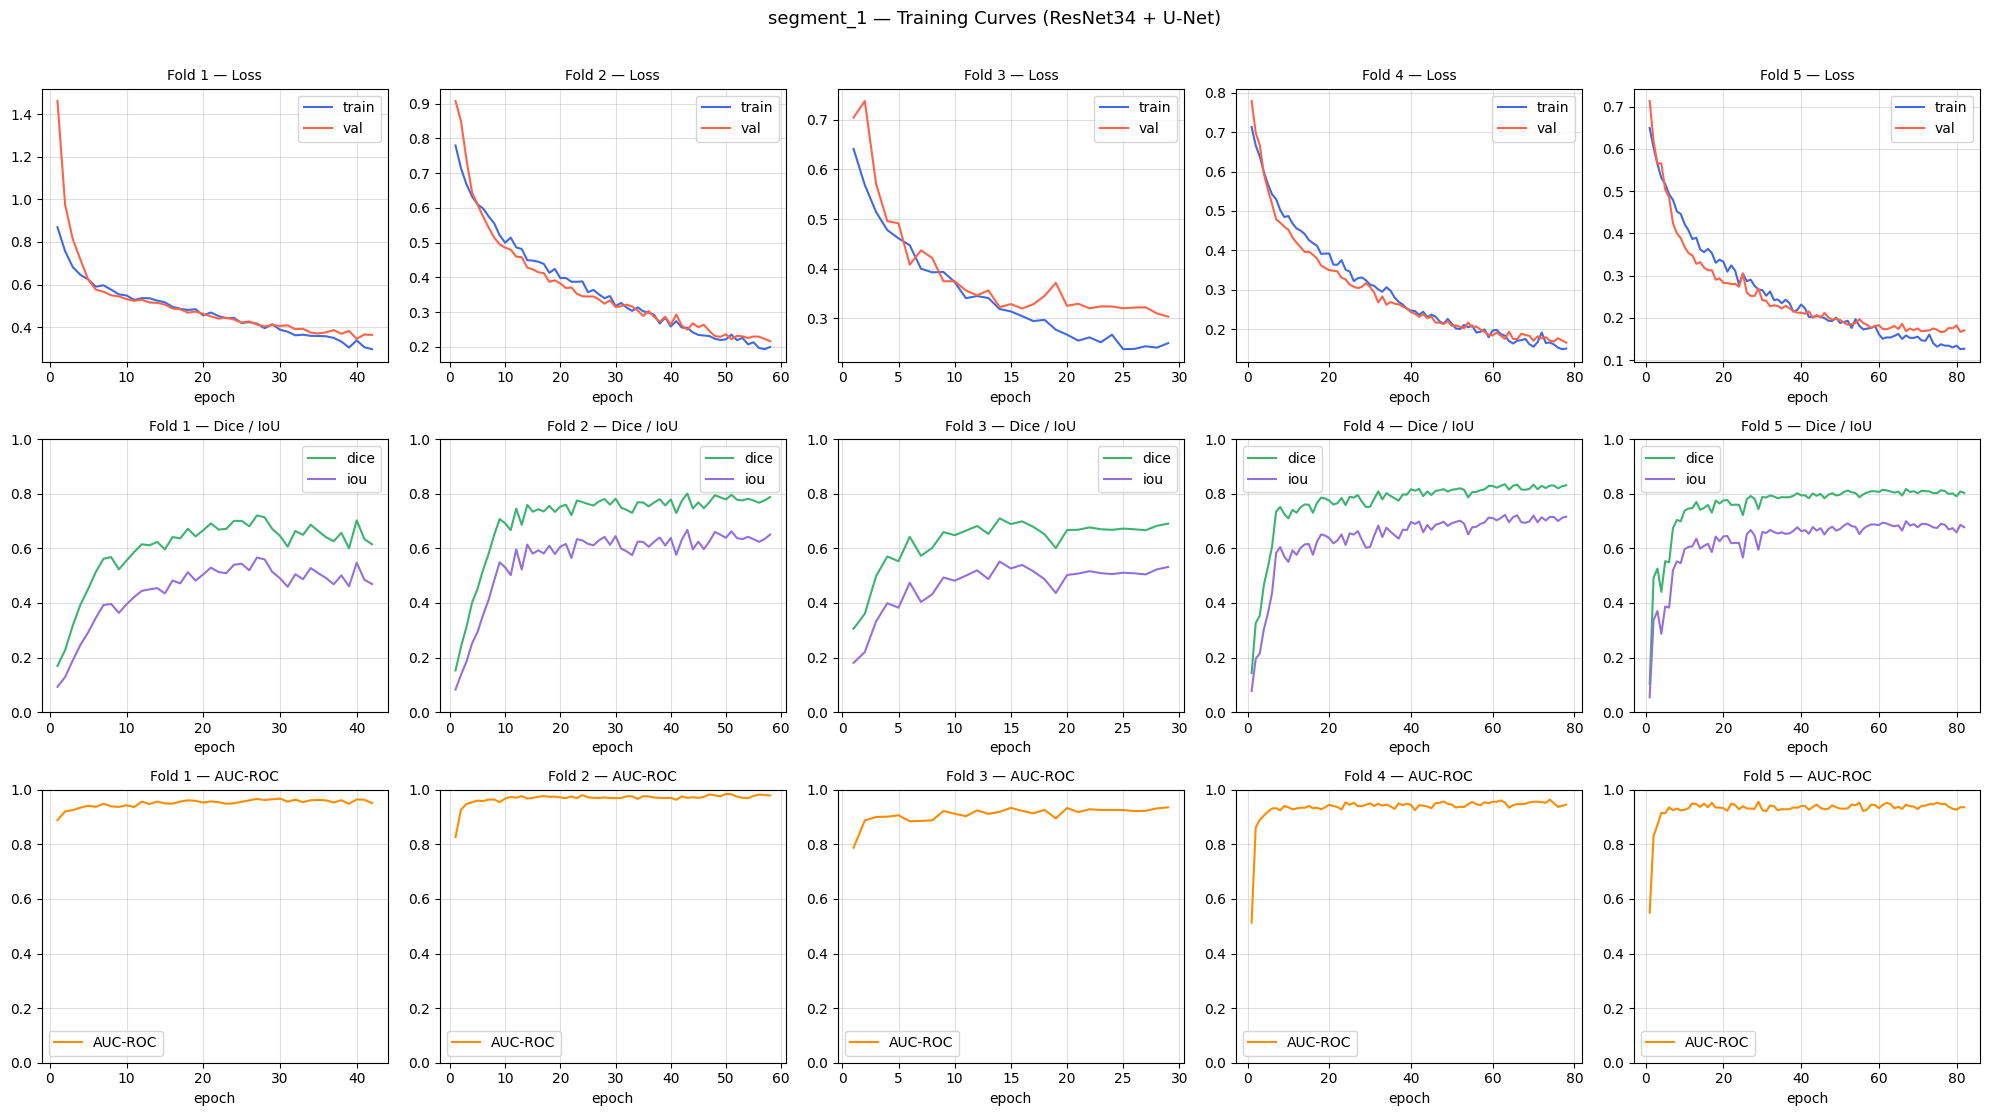

In [15]:
n = config['n_folds']
fig, axes = plt.subplots(3, n, figsize=(4 * n, 11))

for fold, h in enumerate(all_histories):
    ep = range(1, len(h['train_loss']) + 1)

    axes[0, fold].plot(ep, h['train_loss'], label='train', color='royalblue')
    axes[0, fold].plot(ep, h['val_loss'],   label='val',   color='tomato')
    axes[0, fold].set_title(f'Fold {fold+1} — Loss', fontsize=10)
    axes[0, fold].set_xlabel('epoch'); axes[0, fold].legend(); axes[0, fold].grid(alpha=0.4)

    axes[1, fold].plot(ep, h['val_dice'], label='dice', color='mediumseagreen')
    axes[1, fold].plot(ep, h['val_iou'],  label='iou',  color='mediumpurple')
    axes[1, fold].set_ylim(0, 1)
    axes[1, fold].set_title(f'Fold {fold+1} — Dice / IoU', fontsize=10)
    axes[1, fold].set_xlabel('epoch'); axes[1, fold].legend(); axes[1, fold].grid(alpha=0.4)

    aucs = [a for a in h['val_auc'] if not np.isnan(a)]
    if aucs:
        axes[2, fold].plot(range(1, len(aucs) + 1), aucs, label='AUC-ROC', color='darkorange')
    axes[2, fold].set_ylim(0, 1)
    axes[2, fold].set_title(f'Fold {fold+1} — AUC-ROC', fontsize=10)
    axes[2, fold].set_xlabel('epoch'); axes[2, fold].legend(); axes[2, fold].grid(alpha=0.4)

plt.suptitle('segment_1 — Training Curves (ResNet34 + U-Net)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(save_root, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

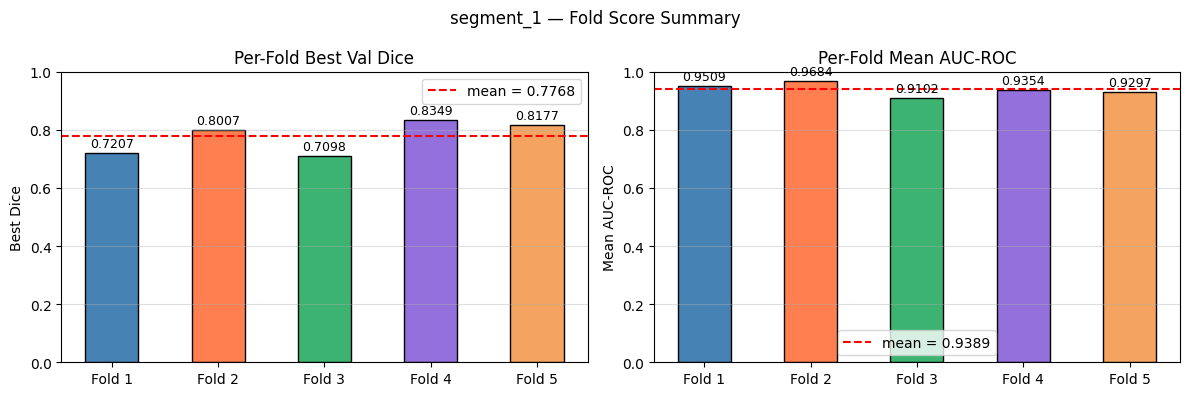

In [16]:
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'sandybrown']
x = np.arange(n)
mean_val = np.mean(fold_scores)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(x, fold_scores, color=colors, edgecolor='black', width=0.5)
axes[0].axhline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'mean = {mean_val:.4f}')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Fold {i+1}' for i in range(n)])
axes[0].set_ylim(0, 1); axes[0].set_ylabel('Best Dice')
axes[0].set_title('Per-Fold Best Val Dice'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.4)
for bar, s in zip(bars, fold_scores):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{s:.4f}',
                 ha='center', va='bottom', fontsize=9)

mean_aucs = [np.nanmean(h['val_auc']) for h in all_histories]
bars2 = axes[1].bar(x, mean_aucs, color=colors, edgecolor='black', width=0.5)
axes[1].axhline(np.nanmean(mean_aucs), color='red', linestyle='--', linewidth=1.5,
                label=f'mean = {np.nanmean(mean_aucs):.4f}')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Fold {i+1}' for i in range(n)])
axes[1].set_ylim(0, 1); axes[1].set_ylabel('Mean AUC-ROC')
axes[1].set_title('Per-Fold Mean AUC-ROC'); axes[1].legend(); axes[1].grid(axis='y', alpha=0.4)
for bar, s in zip(bars2, mean_aucs):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{s:.4f}',
                 ha='center', va='bottom', fontsize=9)

plt.suptitle('segment_1 — Fold Score Summary', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(save_root, 'fold_scores.png'), dpi=150)
plt.show()

## Test Set Evaluation

In [17]:
from sklearn.metrics import roc_curve

test_dataset = BUSIDataset(test_paths, test_labels, val_transform)
test_loader = DataLoader(
    test_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=config['num_workers'],
    pin_memory=True,
)
criterion = SegmentationLoss()

fold_test_dices = []
fold_test_ious = []
fold_test_aucs = []
fold_roc_data = []
fold_ids = []

for fold in range(config['n_folds']):
    ckpt_path = fold_model_path(fold)
    if not os.path.exists(ckpt_path):
        print(f'fold {fold+1}: checkpoint not found, skipping')
        continue

    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model = build_model().to(device)
    model.load_state_dict(ckpt['model_state_dict'])

    _, test_dice, test_iou, test_auc, all_probs, all_targets = validate(model, test_loader, criterion, device)
    fold_test_dices.append(test_dice)
    fold_test_ious.append(test_iou)
    fold_test_aucs.append(test_auc)
    fold_ids.append(fold + 1)

    probs = np.concatenate(all_probs)
    targets = np.concatenate(all_targets).astype(int)
    if targets.sum() > 0 and (1 - targets).sum() > 0:
        fpr, tpr, _ = roc_curve(targets, probs)
        fold_roc_data.append((fold + 1, fpr, tpr, test_auc))

    auc_str = f'{test_auc:.4f}' if not np.isnan(test_auc) else 'n/a'
    print(f'fold {fold+1}  dice {test_dice:.4f}  iou {test_iou:.4f}  auc {auc_str}')

print(f'\nmean dice: {np.mean(fold_test_dices):.4f} ± {np.std(fold_test_dices):.4f}')
print(f'mean iou:  {np.mean(fold_test_ious):.4f} ± {np.std(fold_test_ious):.4f}')
print(f'mean auc:  {np.nanmean(fold_test_aucs):.4f} ± {np.nanstd(fold_test_aucs):.4f}')

fold 1  dice 0.7694  iou 0.6253  auc 0.9684


fold 2  dice 0.7800  iou 0.6396  auc 0.9568


fold 3  dice 0.7470  iou 0.5962  auc 0.9276


fold 4  dice 0.7786  iou 0.6375  auc 0.9594


fold 5  dice 0.8140  iou 0.6870  auc 0.9518

mean dice: 0.7778 ± 0.0216
mean iou:  0.6371 ± 0.0294
mean auc:  0.9528 ± 0.0137


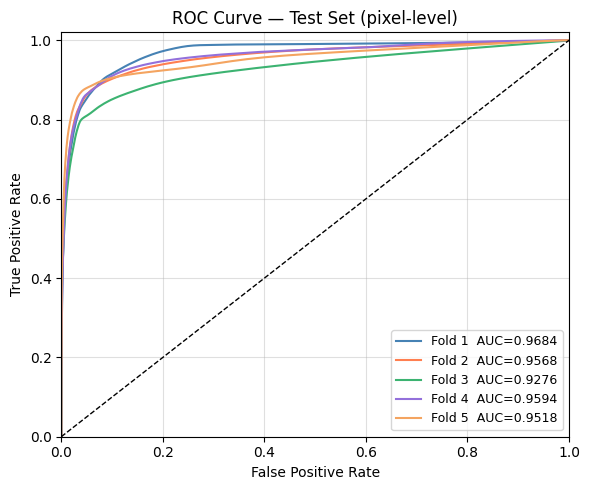

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))

palette = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'sandybrown']
for i, (fold_id, fpr, tpr, auc) in enumerate(fold_roc_data):
    auc_str = f'{auc:.4f}' if not np.isnan(auc) else 'n/a'
    ax.plot(fpr, tpr, color=palette[i % len(palette)], lw=1.5, label=f'Fold {fold_id}  AUC={auc_str}')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Test Set (pixel-level)')
if fold_roc_data:
    ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(save_root, 'roc_curve.png'), dpi=150)
plt.show()

## Summary

In [19]:
rows = []
for idx, fold_id in enumerate(fold_ids):
    rows.append({
        'Fold': fold_id,
        'Val Dice': round(fold_scores[fold_id - 1], 4),
        'Best Epoch': fold_best_epochs[fold_id - 1],
        'Test Dice': round(fold_test_dices[idx], 4),
        'Test IoU': round(fold_test_ious[idx], 4),
        'Test AUC': round(fold_test_aucs[idx], 4) if not np.isnan(fold_test_aucs[idx]) else float('nan'),
        'Checkpoint': os.path.basename(fold_model_path(fold_id - 1)),
    })
rows.append({
    'Fold': 'mean ± std',
    'Val Dice': f'{np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}',
    'Best Epoch': '-',
    'Test Dice': f'{np.mean(fold_test_dices):.4f} ± {np.std(fold_test_dices):.4f}',
    'Test IoU': f'{np.mean(fold_test_ious):.4f} ± {np.std(fold_test_ious):.4f}',
    'Test AUC': f'{np.nanmean(fold_test_aucs):.4f} ± {np.nanstd(fold_test_aucs):.4f}',
    'Checkpoint': os.path.basename(main_model_path),
})

df = pd.DataFrame(rows).set_index('Fold')
print('segment_1 — ResNet34 | U-Net | BCE+Dice | ReduceLROnPlateau | 256px\n')
print(df.to_string())

segment_1 — ResNet34 | U-Net | BCE+Dice | ReduceLROnPlateau | 256px

                   Val Dice Best Epoch        Test Dice         Test IoU         Test AUC           Checkpoint
Fold                                                                                                          
1                    0.7207         27           0.7694           0.6253           0.9684  segment1_fold_1.pth
2                    0.8007         43             0.78           0.6396           0.9568  segment1_fold_2.pth
3                    0.7098         14            0.747           0.5962           0.9276  segment1_fold_3.pth
4                    0.8349         63           0.7786           0.6375           0.9594  segment1_fold_4.pth
5                    0.8177         67            0.814            0.687           0.9518  segment1_fold_5.pth
mean ± std  0.7768 ± 0.0515          -  0.7778 ± 0.0216  0.6371 ± 0.0294  0.9528 ± 0.0137         segment1.pth


## Qualitative Visualization

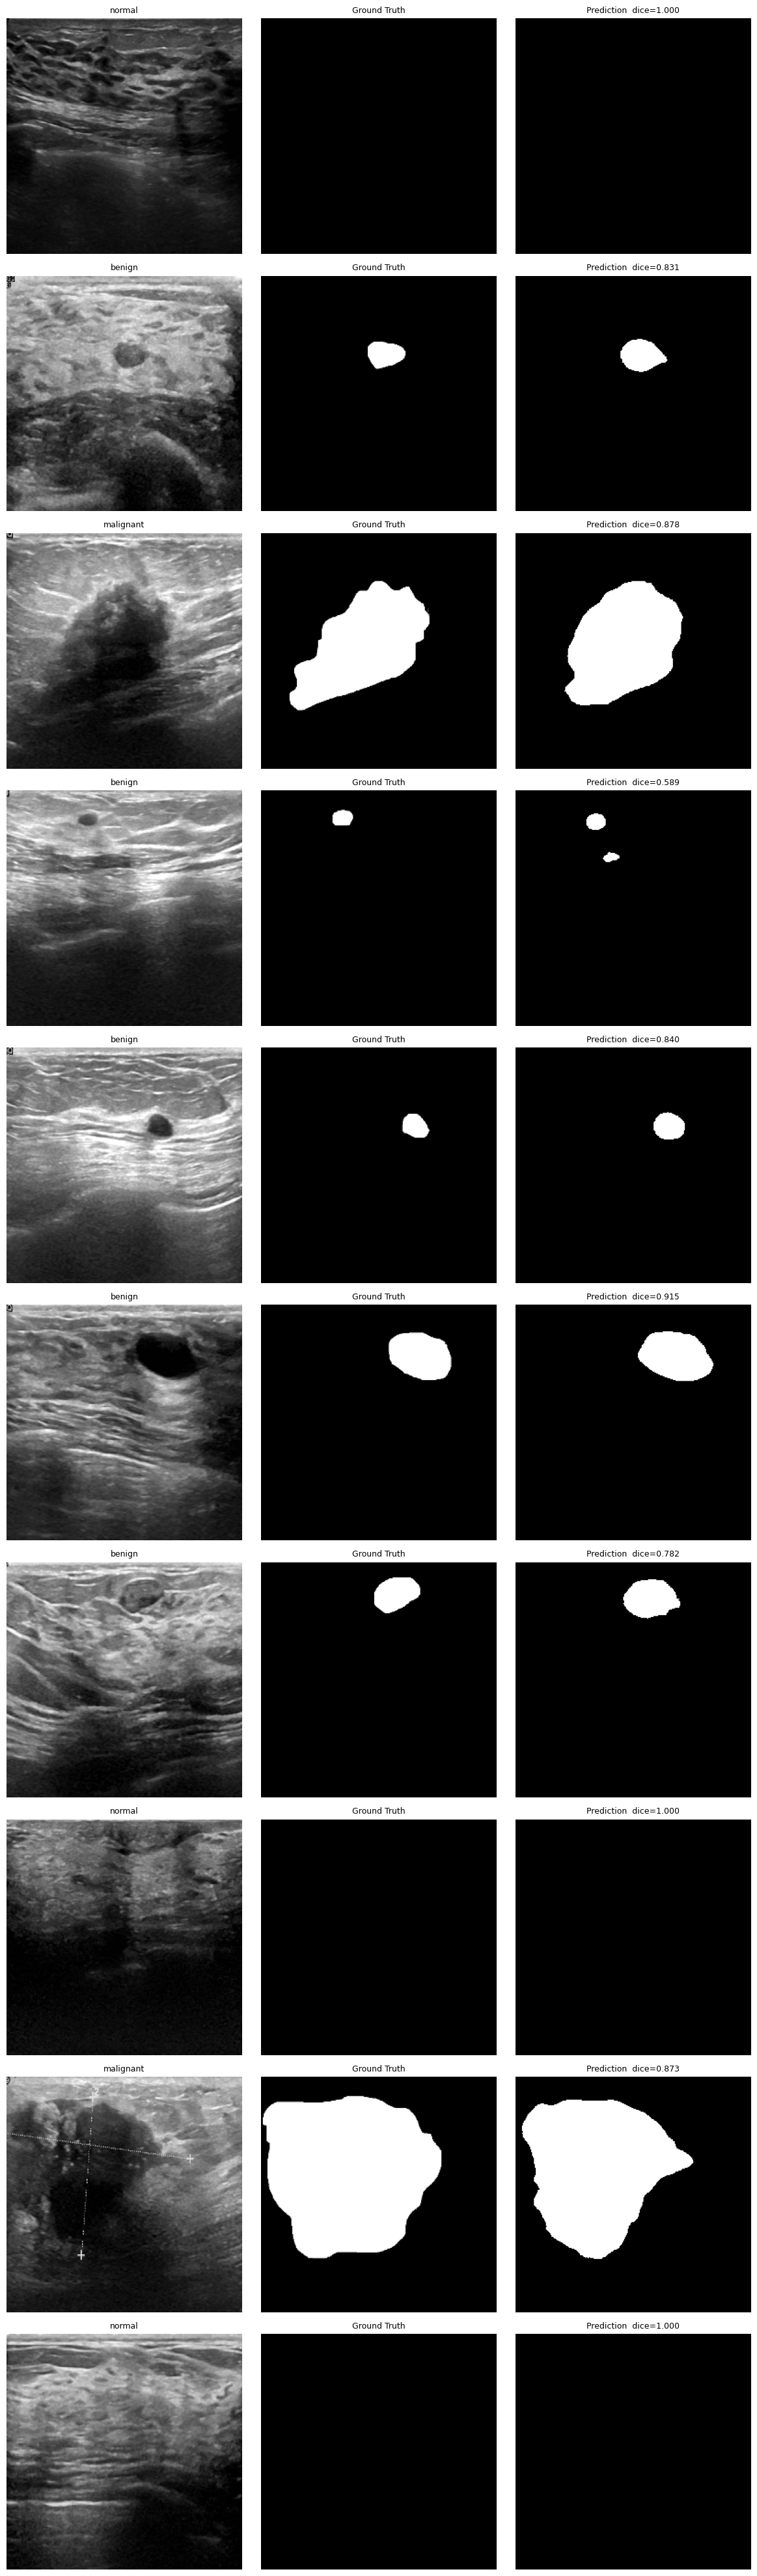

In [20]:
best_fold = int(np.argmax(fold_scores))
ckpt = torch.load(fold_model_path(best_fold), map_location=device, weights_only=False)
vis_model = build_model().to(device)
vis_model.load_state_dict(ckpt['model_state_dict'])
vis_model.eval()

sample_indices = random.sample(range(len(test_paths)), min(10, len(test_paths)))
mean_np = np.array([0.485, 0.456, 0.406])
std_np = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(len(sample_indices), 3, figsize=(12, 4 * len(sample_indices)))
axes = np.atleast_2d(axes)

for row, idx in enumerate(sample_indices):
    img_path = test_paths[idx]
    label = test_labels[idx]

    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rs = cv2.resize(img_rgb, (config['input_size'], config['input_size']))

    mask_raw = load_all_masks(img_path)
    if mask_raw is not None:
        gt_mask = cv2.resize(mask_raw, (config['input_size'], config['input_size'])) / 255.0
    else:
        gt_mask = np.zeros((config['input_size'], config['input_size']), dtype=np.float32)

    norm_img = ((img_rs / 255.0) - mean_np) / std_np
    tensor_img = torch.tensor(norm_img.transpose(2, 0, 1), dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_logit = vis_model(tensor_img)
        pred_prob = torch.sigmoid(pred_logit).squeeze().cpu().numpy()

    pred_binary = (pred_prob > 0.5).astype(np.float32)
    intersection = (pred_binary * gt_mask).sum()
    dsc = (2.0 * intersection + 1e-6) / (pred_binary.sum() + gt_mask.sum() + 1e-6)

    axes[row, 0].imshow(img_rs)
    axes[row, 0].set_title(label, fontsize=9)
    axes[row, 1].imshow(gt_mask, cmap='gray')
    axes[row, 1].set_title('Ground Truth', fontsize=9)
    axes[row, 2].imshow(pred_binary, cmap='gray')
    axes[row, 2].set_title(f'Prediction  dice={dsc:.3f}', fontsize=9)

    for ax in axes[row]:
        ax.axis('off')

plt.suptitle(f'Qualitative Results — best fold {best_fold + 1}', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(save_root, 'qualitative_viz.png'), dpi=150)
plt.show()